In [10]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import load
import tensorflow as tf
from tensorflow import keras
np.random.seed(42)
print("TensorFlow:", tf.__version__)

TensorFlow: 2.16.2


In [11]:
CSV_PATH = Path("../csv/merged_ML_ch2-pb80.csv")

# stage-1 artifacts
S1_DIR    = Path("models_stage1_unmatched_vs_matched")
S1_MODEL  = S1_DIR / "stage1_unmatched_vs_matched_dnn_best.keras"
S1_PREP   = S1_DIR / "stage1_preprocess.joblib"     # bare sklearn Pipeline

# stage-2 artifacts
S2_DIR    = Path("models_stage2_qqbar_binary")
S2_MODEL  = S2_DIR / "qqbar_binary_dnn_best.keras"
S2_PREP   = S2_DIR / "qqbar_binary_preprocessor.joblib"   # dict: imputer/scaler/features

OUTPUT_DIR = Path("outputs_twostage_600to800")
OUTPUT_DIR.mkdir(exist_ok=True)

STAGE1_THRESHOLD = 0.0  # keep jets with matched-score > this

for p in [CSV_PATH, S1_MODEL, S1_PREP, S2_MODEL, S2_PREP]:
    if not p.exists():
        raise FileNotFoundError(f"Missing: {p.resolve()}")
print("All artifacts found.")

All artifacts found.


In [12]:
def engineer_stage1(df):
    """Exact stage-1 engineering (includes deltaR34 log-transform)."""
    df = df.copy()
    for col in ["pt_dispersion3", "pt_dispersion4"]:
        if col in df.columns:
            df[col] = np.log1p(df[col].clip(lower=0))
    if "kt2" in df.columns:
        df["kt2"] = np.log1p(df["kt2"].clip(lower=0))
    if "deltaR34" in df.columns:
        dr = df["deltaR34"].clip(lower=1e-4)
        df["deltaR34"] = np.log1p(1.0 / dr)
    df["z_sum"]=df["z1"]+df["z2"]; df["z_absdiff"]=np.abs(df["z1"]-df["z2"])
    df["z_min"]=np.minimum(df["z1"],df["z2"]); df["z_max"]=np.maximum(df["z1"],df["z2"])
    df["z_minmax_ratio"]=df["z_min"]/(df["z_max"]+1e-8)
    for c3,c4,name in [("N_charged3","N_charged4","N_charged"),("N_all3","N_all4","N_all"),
                       ("pt_weight3","pt_weight4","pt_weight"),
                       ("pt_dispersion3","pt_dispersion4","pt_dispersion")]:
        if c3 in df.columns and c4 in df.columns:
            v3,v4=df[c3],df[c4]; vmin,vmax=np.minimum(v3,v4),np.maximum(v3,v4)
            df[f"{name}_sum"]=v3+v4; df[f"{name}_absdiff"]=np.abs(v3-v4)
            df[f"{name}_min"]=vmin; df[f"{name}_max"]=vmax
            df[f"{name}_minmax_ratio"]=vmin/(vmax+1e-8)
    return df

def engineer_stage2(df):
    """Exact stage-2 engineering (no deltaR34 transform)."""
    df = df.copy()
    for col in ["pt_dispersion3", "pt_dispersion4"]:
        if col in df.columns:
            df[col] = np.log1p(df[col].clip(lower=0))
    if "kt2" in df.columns:
        df["kt2"] = np.log1p(df["kt2"].clip(lower=0))
    df["z_sum"]=df["z1"]+df["z2"]; df["z_absdiff"]=np.abs(df["z1"]-df["z2"])
    df["z_min"]=np.minimum(df["z1"],df["z2"]); df["z_max"]=np.maximum(df["z1"],df["z2"])
    df["z_minmax_ratio"]=df["z_min"]/(df["z_max"]+1e-8)
    for c3,c4,name in [("N_charged3","N_charged4","N_charged"),("N_all3","N_all4","N_all"),
                       ("pt_weight3","pt_weight4","pt_weight"),
                       ("pt_dispersion3","pt_dispersion4","pt_dispersion")]:
        if c3 in df.columns and c4 in df.columns:
            v3,v4=df[c3],df[c4]; vmin,vmax=np.minimum(v3,v4),np.maximum(v3,v4)
            df[f"{name}_sum"]=v3+v4; df[f"{name}_absdiff"]=np.abs(v3-v4)
            df[f"{name}_min"]=vmin; df[f"{name}_max"]=vmax
            df[f"{name}_minmax_ratio"]=vmin/(vmax+1e-8)
    return df

In [13]:
df0 = pd.read_csv(CSV_PATH)
print("Raw shape:", df0.shape)

ORIGINAL_TARGET = "channel2"
for req in [ORIGINAL_TARGET, "dpsi12"]:
    if req not in df0.columns:
        raise ValueError(f"CSV missing required column '{req}'")

# stage-1 was trained on channel2 in {0,1,2,3} (matched vs unmatched).
df0 = df0[df0[ORIGINAL_TARGET].isin([0,1,2,3])].copy().reset_index(drop=True)
df0["row_id"] = np.arange(len(df0))   # stable id to carry through both stages
print("Rows (channel2 in 0..3):", len(df0))

Raw shape: (25131, 18)
Rows (channel2 in 0..3): 24960


In [14]:
# --- stage-1 preprocessor (Pipeline) + model ---
prep1 = load(S1_PREP)

# Recover the EXACT feature names the pipeline was fit on.
# SimpleImputer stores them in feature_names_in_.
s1_features = list(prep1.named_steps["imputer"].feature_names_in_)
print("Stage-1 expects", len(s1_features), "features")

# Build stage-1 inputs from the RAW dataframe (stage-1 did NOT engineer features).
d1 = df0.copy()
missing = [c for c in s1_features if c not in d1.columns]
if missing:
    raise ValueError(f"Stage-1 features missing from CSV: {missing}")
X1 = d1[s1_features].replace([np.inf, -np.inf], np.nan)

X1_pp = prep1.transform(X1).astype("float32")

m1 = keras.models.load_model(S1_MODEL, compile=False)
pred1 = m1.predict(X1_pp, batch_size=4096, verbose=1)

matched_score = pred1[:, 1] if (pred1.ndim == 2 and pred1.shape[1] == 2) else pred1.ravel()
df0["stage1_matched_score"] = matched_score

keep_mask = matched_score > STAGE1_THRESHOLD
print(f"Stage-1: {keep_mask.sum():,} / {len(df0):,} jets pass matched-score > {STAGE1_THRESHOLD}")
df_matched = df0[keep_mask].copy().reset_index(drop=True)

true_matched = (df_matched["channel2"] != 0).mean()
print(f"Stage-1 selected sample is {true_matched:.3%} truly matched (channel2 != 0)")

Stage-1 expects 12 features
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Stage-1: 24,960 / 24,960 jets pass matched-score > 0.0
Stage-1 selected sample is 6.258% truly matched (channel2 != 0)


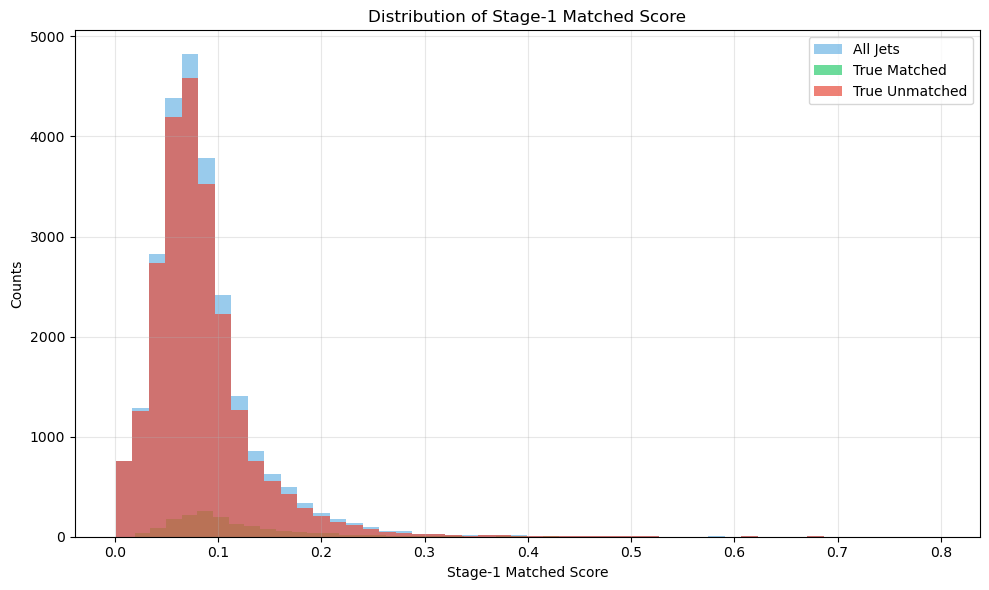

In [15]:
# Plot the distribution of stage1_matched_score for all, true matched, and true unmatched
plt.figure(figsize=(10, 6))

# All dataset
plt.hist(df0["stage1_matched_score"], bins=50, color="#3498db", alpha=0.5, label="All Jets")

# True matched (channel2 != 0)
plt.hist(df0[df0["channel2"] != 0]["stage1_matched_score"], bins=50, color="#2ecc71", alpha=0.7, label="True Matched")

# True unmatched (channel2 == 0)
plt.hist(df0[df0["channel2"] == 0]["stage1_matched_score"], bins=50, color="#e74c3c", alpha=0.7, label="True Unmatched")

# Add labels, legend, and title
plt.xlabel("Stage-1 Matched Score")
plt.ylabel("Counts")
plt.title("Distribution of Stage-1 Matched Score")
plt.legend()
plt.grid(alpha=0.3)

# Save and show the plot
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "matched_score_vs_counts_all_true_matched_unmatched.png", dpi=150)
plt.show()

In [16]:
# Load the stage-2 preprocessor
prep2 = load(S2_PREP)

# Extract the imputer, scaler, and feature names from the preprocessor
imp2, scl2, feat2 = prep2["imputer"], prep2["scaler"], prep2["features"]

# Apply stage-2 engineering to the entire dataset
d2 = engineer_stage2(df0)

# Check for missing features in the dataset
missing = [c for c in feat2 if c not in d2.columns]
if missing:
    raise ValueError(f"Stage-2 missing feature columns: {missing}")

# Extract the features for stage-2 preprocessing
X2 = d2[feat2]

# Apply the imputer and scaler to the entire dataset
X2_pp = scl2.transform(imp2.transform(X2)).astype("float32")

# Now X2_pp contains the preprocessed features for the entire dataset
print("Stage-2 preprocessing applied to the entire dataset.")

Stage-2 preprocessing applied to the entire dataset.


In [17]:
model = keras.models.load_model(S2_MODEL, compile=False)
df0["score"] = model.predict(X2_pp, batch_size=4096, verbose=1).ravel()

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


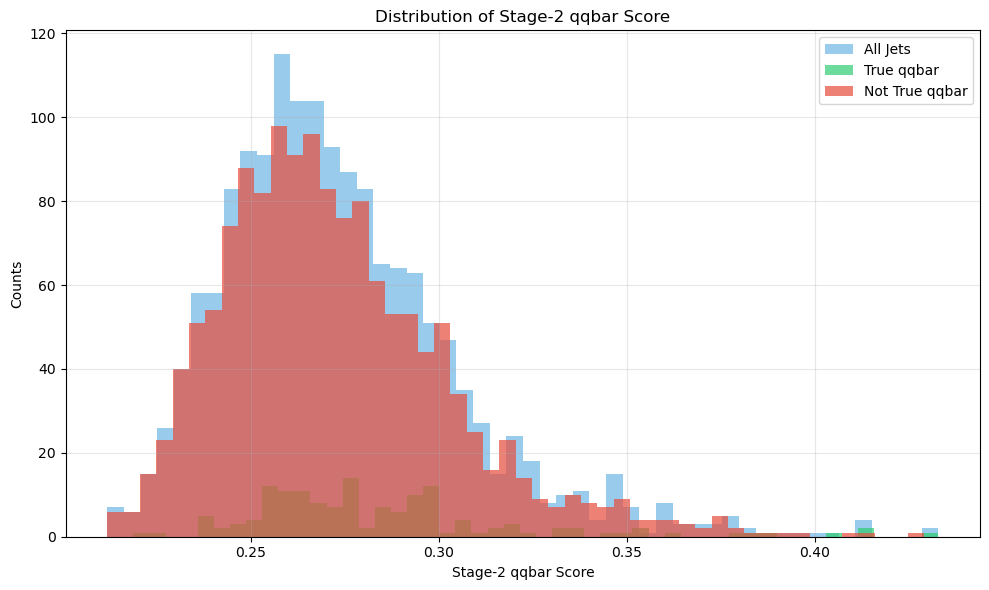

In [18]:
# Create the 'is_qqbar' column based on 'channel2'
df0["is_qqbar"] = (df0["channel2"] == 1).astype(int)

# Drop "channel2" == 0 rows for plotting, as they are not relevant for qqbar analysis
df0 = df0[df0["channel2"] != 0].copy().reset_index(drop=True)

# Now proceed with the plotting
plt.figure(figsize=(10, 6))

# All dataset
plt.hist(df0["score"], bins=50, color="#3498db", alpha=0.5, label="All Jets")

# True qqbar (is_qqbar == 1)
plt.hist(df0[df0["is_qqbar"] == 1]["score"], bins=50, color="#2ecc71", alpha=0.7, label="True qqbar")

# Not true qqbar (is_qqbar == 0)
plt.hist(df0[df0["is_qqbar"] == 0]["score"], bins=50, color="#e74c3c", alpha=0.7, label="Not True qqbar")

# Add labels, legend, and title
plt.xlabel("Stage-2 qqbar Score")
plt.ylabel("Counts")
plt.title("Distribution of Stage-2 qqbar Score")
plt.legend()
plt.grid(alpha=0.3)

# Save and show the plot
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "qqbar_score_vs_counts_all_true_not_true.png", dpi=150)
plt.show()